## *Example 1     $\hspace{10mm} \displaystyle \frac{du}{d\tau} = 1 - u^2$*

Here we will only look at one variable, the dimensionless velocity $u$ (we could solve for $u$ and (dimensionless) position $x$, but will do that in Example 2).

y_sol = [[0.         0.29139548 0.53724021 0.7162084  0.83292152 0.90498676
  0.9468008  0.97042136 0.98372022 0.99097211 0.99500995]]

type(t_sol) = <class 'numpy.ndarray'>
type(y_sol) = <class 'numpy.ndarray'>
y_sol.shape = (1, 11)


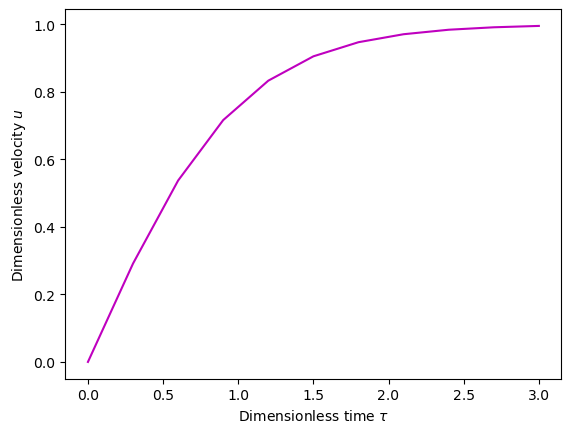

In [19]:
from scipy import integrate
import matplotlib.pyplot as plt
import numpy as np


def dydt_arr(t, y_arr):
    """
    This returns dv/dt as an array, even when there 
    is only one variable, y0, like in this case
    """
    v = y_arr[0]  # Velocity (y0), the first and only element in y_arr
    return np.array([1.0 - v**2])


v0 = 0.0  # Initial condition v(t=0)
y0_arr = np.array([v0])  # array for dydt_arr initial condition
t0 = 0.0  # initial time
tmax = 3.0  # maximum time
steps = 10  # number of time steps
dt = (tmax - t0) / steps  # size of the time step

# Create the 1d array for time values
t_arr = t0 + np.arange(steps + 1) * dt

# t_eval = t_arr specifies the times at which we'd like to see the solutions
sol = integrate.solve_ivp(dydt_arr, (t_arr[0], t_arr[-1]),
                          y0_arr,
                          t_eval=t_arr,
                          method='LSODA')

t_sol = sol['t']
y_sol = sol['y']

print('y_sol =', y_sol)

# The data types used in the code
print('\ntype(t_sol) =', type(t_sol))
print('type(y_sol) =', type(y_sol))
print('y_sol.shape =', y_sol.shape)

# Let's also plot ysol_arr[0,:] (velocity) as a function of t_arr (time)
#plt.figure(dpi=200)
plt.plot(t_sol, y_sol[0, :], 'm-')
plt.xlabel(r"Dimensionless time $\tau$")
plt.ylabel(r"Dimensionless velocity $u$")
plt.show()

## *Example 2 $\hspace{10mm} \displaystyle \frac{dv}{d\tau} = -l - \gamma v \hspace{10mm} \frac{dl}{d\tau} = v$*

For this example we are interested in two variables, dimensionless position $l$, and dimensionless velocity $v$, so we have two physical quantities, $y_0$ and $y_1$, respectively. The single 2nd-order differential equation is broken into two 1st-order equations. We'll set $\gamma = 0.1$. The code is:

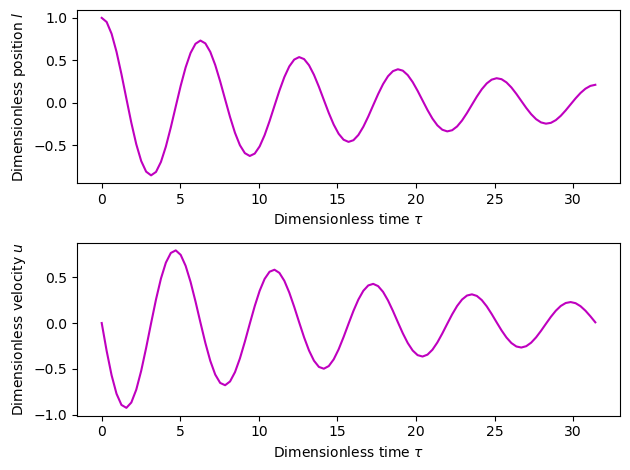

In [18]:
def dydt_arr(t, y_arr):
    x = y_arr[0]  # Position (1st element of y_arr)
    v = y_arr[1]  # Velocity (2dn element of y_arr)
    return np.array([v, -x - gamma * v])  # This is [dx/dt, dv/dt]


gamma = 0.1  # damping constant
t0 = 0.0
tmax = 10.0 * np.pi  # final time
steps = 100

t_arr = np.linspace(t0, tmax, steps + 1)  # 1d time array

# Initial condition for position, velocity
y0_arr = [1.0, 0.0]

# Solve the differential equation:
sol = integrate.solve_ivp(dydt_arr, (t_arr[0], t_arr[-1]),
                          y0_arr,
                          t_eval=t_arr,
                          method='LSODA')

t_sol = sol['t']
y_sol = sol['y']

# Let's also plot ysol_arr[0,:] (velocity) as a function of t_arr (time)
plt.subplot(211)  # Two rows, one column, top plot
plt.plot(t_sol, y_sol[0, :], 'm-')
plt.xlabel(r"Dimensionless time $\tau$")
plt.ylabel(r"Dimensionless position $l$")

plt.subplot(212)  # Two rows, one column, bottom plot
plt.plot(t_sol, y_sol[1, :], 'm-')
plt.xlabel(r"Dimensionless time $\tau$")
plt.ylabel(r"Dimensionless velocity $u$")
plt.tight_layout()  # spreads subplots out
plt.show()

Experiment with different values of $\gamma$ to see how the results change.